# Metropolis Algorithm for Spin Configurations

This notebook now matches the **spin-flip Metropolis algorithm** you described.

Given a configuration
$$
\alpha_k = \{s_1, s_2, \dots, s_N\}, \quad s_i \in \{-1,+1\},
$$
we produce a candidate by:
1. Picking a random site $i$.
2. Flipping $s_i \to -s_i$.
3. Computing $\Delta E = E_{\text{trial}} - E_{\alpha_k}$.
4. Accepting automatically if $\Delta E \le 0$.
5. If $\Delta E > 0$, accepting with
$$
\mathcal{R} = \exp\left(-\frac{\Delta E}{k_B T}\right)
$$
by comparing to a uniform random number $r \in [0,1]$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def ising_energy(spins, J=1.0, h=0.0):
    """Total energy for 1D Ising chain with periodic boundary conditions.

    E = -J * sum_i s_i s_{i+1} - h * sum_i s_i
    """
    spins = np.asarray(spins, dtype=np.int8)
    return float(-J * np.sum(spins * np.roll(spins, -1)) - h * np.sum(spins))


def spins_to_pm_string(s):
    """Return a + / - string for an Ising spin array s[N]."""
    s = np.asarray(s, dtype=np.int8)
    return "".join("+" if si > 0 else "-" for si in s)


def metropolis_spin_flip_step(alpha_k, T, J=1.0, h=0.0, kB=1.0, rng=None):
    """One Metropolis update producing alpha_{k+1} from alpha_k.

    Steps:
      a) pick random spin index i
      b) flip s_i to create trial configuration
      c) compute DeltaE = E_trial - E_current
      d) accept if DeltaE <= 0
      e) else accept with probability exp(-DeltaE/(kB*T))
    """
    if rng is None:
        rng = np.random.default_rng()

    alpha_k = np.asarray(alpha_k, dtype=np.int8)
    N = alpha_k.size

    # 2a) Pick random particle/site i
    i = int(rng.integers(0, N))

    # 2b) Trial by flipping spin i
    alpha_tr = alpha_k.copy()
    alpha_tr[i] *= -1

    E_current = ising_energy(alpha_k, J=J, h=h)
    E_trial = ising_energy(alpha_tr, J=J, h=h)
    delta_E = E_trial - E_current

    # 4) Accept automatically if energy goes down
    if delta_E <= 0.0:
        return alpha_tr, True, i, delta_E

    # 5) Accept with relative probability R = exp(-DeltaE/(kB*T))
    R = np.exp(-delta_E / (kB * T))
    r = rng.random()
    if R >= r:
        return alpha_tr, True, i, delta_E

    return alpha_k, False, i, delta_E

## Example: 1D Ising model (periodic chain)

We simulate a chain of $N$ spins with energy
$$
E(\alpha) = -J\sum_{i=1}^{N} s_i s_{i+1} - h\sum_{i=1}^{N} s_i,
$$
with $s_{N+1}\equiv s_1$ (periodic boundary).

In [4]:
# Parameters
rng = np.random.default_rng(42)
N = 80
T = 2.0
J = 1.0
h = 0.0
kB = 1.0

# Step 1: arbitrary initial spin configuration alpha_k = {s1, ..., sN}
alpha_k = rng.choice(np.array([-1, 1], dtype=np.int8), size=N)

In [5]:
# Run Metropolis updates
n_steps = 40000
burn_in = 5000

magnetization_trace = np.empty(n_steps, dtype=float)
energy_trace = np.empty(n_steps, dtype=float)
accepted_trace = np.empty(n_steps, dtype=bool)

# Debug trial numbers to inspect lattice spin pattern as + / -
debug_trials = {1, 2, 3, 5, 10, 20, 50, 100}

print("Initial s[N] pattern:")
print(spins_to_pm_string(alpha_k))
print()

for k in range(n_steps):
    alpha_k1, accepted, flipped_index, delta_E = metropolis_spin_flip_step(
        alpha_k=alpha_k,
        T=T,
        J=J,
        h=h,
        kB=kB,
        rng=rng
    )
    alpha_k = alpha_k1
    accepted_trace[k] = accepted
    magnetization_trace[k] = np.mean(alpha_k)
    energy_trace[k] = ising_energy(alpha_k, J=J, h=h)

    trial_number = k + 1
    if trial_number in debug_trials:
        status = "accepted" if accepted else "rejected"
        print(f"Trial {trial_number:>3}: flip index {flipped_index:>2}, ΔE={delta_E:>5.1f}, {status}")
        print(spins_to_pm_string(alpha_k))
        print()

accept_rate = float(np.mean(accepted_trace))

print(f"N = {N}, T = {T}, J = {J}, h = {h}, kB = {kB}")
print(f"Total steps: {n_steps}")
print(f"Burn-in: {burn_in}")
print(f"Acceptance rate: {accept_rate:.3f}")
print(f"Mean magnetization after burn-in: {magnetization_trace[burn_in:].mean():.4f}")
print(f"Mean energy after burn-in: {energy_trace[burn_in:].mean():.4f}")

Initial s[N] pattern:
-++--+-+--+++++++-+-+--+++-++----++-++-+-++--+-++++-----+-++++-+--+---+---+---++

Trial   1: flip index 75, ΔE=  0.0, accepted
-++--+-+--+++++++-+-+--+++-++----++-++-+-++--+-++++-----+-++++-+--+---+---++--++

Trial   2: flip index 34, ΔE=  0.0, accepted
-++--+-+--+++++++-+-+--+++-++----+--++-+-++--+-++++-----+-++++-+--+---+---++--++

Trial   3: flip index 12, ΔE=  4.0, rejected
-++--+-+--+++++++-+-+--+++-++----+--++-+-++--+-++++-----+-++++-+--+---+---++--++

Trial   5: flip index  7, ΔE= -4.0, accepted
-++--+----+++++++-+-+--+++-++----+--++-+-++--+-++++-----+-++++-+------+---++--++

Trial  10: flip index 30, ΔE=  4.0, rejected
-++--+----+++++++-+-+--+++-++----++-++-+-++--+-++++-----+-++++-++-----+---++--++

Trial  20: flip index 62, ΔE=  0.0, accepted
+++--+----+++++++-+-+-++++-++----++-++-+-++--+-+++------+-+++++-------+---++--++

Trial  50: flip index 52, ΔE=  4.0, rejected
+++-++----+-+++++++-+---++-++---++++-+-++++-++-++++-----+-+++++-------+--+++----

Trial 1

### JC: OK i checked the flipping and for each index it did the right flip

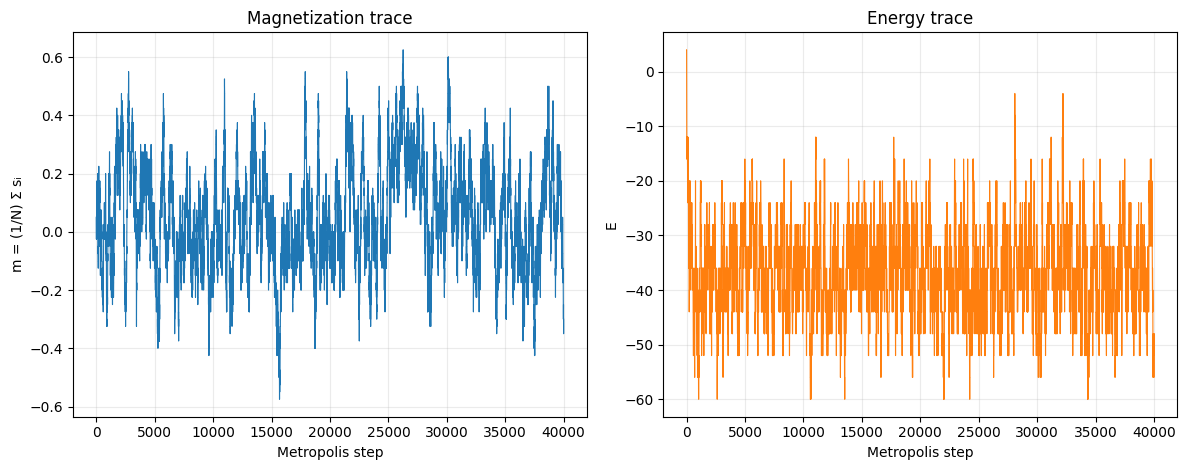

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(magnetization_trace, lw=0.8)
axes[0].set_title("Magnetization trace")
axes[0].set_xlabel("Metropolis step")
axes[0].set_ylabel("m = (1/N) Σ sᵢ")
axes[0].grid(alpha=0.25)

axes[1].plot(energy_trace, lw=0.8, color="tab:orange")
axes[1].set_title("Energy trace")
axes[1].set_xlabel("Metropolis step")
axes[1].set_ylabel("E")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

### JC: the magnetization trace seems about right but also why is energy negative?

### JC: the energy is negative because of the spin change and it being converted into a different type of energy.

## Debug/production settings and equilibration checks

Following your instructions:

- Keep exchange energy fixed at $J=1$ (ferromagnet).
- Use $k_B T = 1$ for debugging.
- Use periodic boundary conditions (already built into `ising_energy` via `np.roll`).
- Use $N\approx 20$ for debug printouts, then larger $N$ for production.

Next cells compare equilibration for:
1. **Cold start** (totally ordered, all spins +1).
2. **Hot start** (random spins ±1).

In [7]:
def run_ising_metropolis(
    N,
    T,
    n_steps,
    start_mode="hot",
    J=1.0,
    h=0.0,
    kB=1.0,
    seed=12,
    debug_trials=None,
):
    """Run 1D Ising Metropolis and optionally print + / - spin patterns."""
    rng_local = np.random.default_rng(seed)

    # Key data structure: s[N]
    if start_mode == "cold":
        s = np.ones(N, dtype=np.int8)
    elif start_mode == "hot":
        s = rng_local.choice(np.array([-1, 1], dtype=np.int8), size=N)
    else:
        raise ValueError("start_mode must be 'cold' or 'hot'.")

    mag = np.empty(n_steps, dtype=float)
    ene = np.empty(n_steps, dtype=float)
    accepted = np.empty(n_steps, dtype=bool)
    spin_history = np.empty((n_steps, N), dtype=np.int8)

    debug_trials = set() if debug_trials is None else set(debug_trials)

    print(f"Start mode: {start_mode}, N={N}, J={J}, kB*T={kB*T}")
    print("Initial s[N]:")
    print(spins_to_pm_string(s))
    print()

    for k in range(n_steps):
        s_next, was_accepted, i_flip, dE = metropolis_spin_flip_step(
            alpha_k=s,
            T=T,
            J=J,
            h=h,
            kB=kB,
            rng=rng_local,
        )
        s = s_next
        accepted[k] = was_accepted
        mag[k] = np.mean(s)
        ene[k] = ising_energy(s, J=J, h=h)
        spin_history[k] = s

        trial = k + 1
        if trial in debug_trials:
            status = "accepted" if was_accepted else "rejected"
            print(f"Trial {trial:>3}: flip index {i_flip:>2}, ΔE={dE:>5.1f}, {status}")
            print(spins_to_pm_string(s))
            print()

    return {
        "s_final": s,
        "mag_trace": mag,
        "ene_trace": ene,
        "accept_rate": float(np.mean(accepted)),
        "accepted_trace": accepted,
        "spin_history": spin_history,
    }


def plot_ising_run_diagnostics(result, title="Ising Metropolis run"):
    """Plot magnetization/energy traces and position-vs-time spin map."""
    mag = result["mag_trace"]
    ene = result["ene_trace"]
    spin_history = result["spin_history"]

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

    axes[0].plot(mag, lw=0.8)
    axes[0].set_title(f"{title}\nMagnetization trace")
    axes[0].set_xlabel("Metropolis step")
    axes[0].set_ylabel("m = (1/N) Σ sᵢ")
    axes[0].grid(alpha=0.25)

    axes[1].plot(ene, lw=0.8, color="tab:orange")
    axes[1].set_title(f"{title}\nEnergy trace")
    axes[1].set_xlabel("Metropolis step")
    axes[1].set_ylabel("E")
    axes[1].grid(alpha=0.25)

    # Transpose so x-axis is time step and y-axis is position index i
    im = axes[2].imshow(
        spin_history.T,
        cmap="grey",
        vmin=-1,
        vmax=1,
        aspect="auto",
        origin="lower",
        interpolation="nearest",
    )
    axes[2].set_title(f"{title}\n1D Ising: position vs time")
    axes[2].set_xlabel("Time step")
    axes[2].set_ylabel("Position index i")

    cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_label("Spin sᵢ")
    cbar.set_ticks([-1, 1])
    cbar.set_ticklabels(["-1", "+1"])

    plt.tight_layout()
    plt.show()

=== Cold start equilibration (ordered initial state) ===
Start mode: cold, N=20, J=1.0, kB*T=1.0
Initial s[N]:
++++++++++++++++++++

Trial   1: flip index 18, ΔE=  4.0, rejected
++++++++++++++++++++

Trial   2: flip index 12, ΔE=  4.0, rejected
++++++++++++++++++++

Trial   3: flip index 16, ΔE=  4.0, rejected
++++++++++++++++++++

Trial   5: flip index 18, ΔE=  4.0, rejected
++++++++++++++++++++

Trial  10: flip index  5, ΔE=  4.0, rejected
++++++++++++++++++++

Trial  20: flip index 18, ΔE=  4.0, rejected
++++++++++++++++++++

Trial  50: flip index  3, ΔE=  4.0, rejected
++++++++-------+++++

Trial 100: flip index  3, ΔE=  0.0, accepted
++--++++--------++++

Trial 200: flip index  7, ΔE=  4.0, rejected
+++++---------++++++

Trial 300: flip index 18, ΔE=  4.0, rejected
++++-----+++++++++++

Cold-start acceptance rate: 0.257
Cold-start final magnetization: 0.500


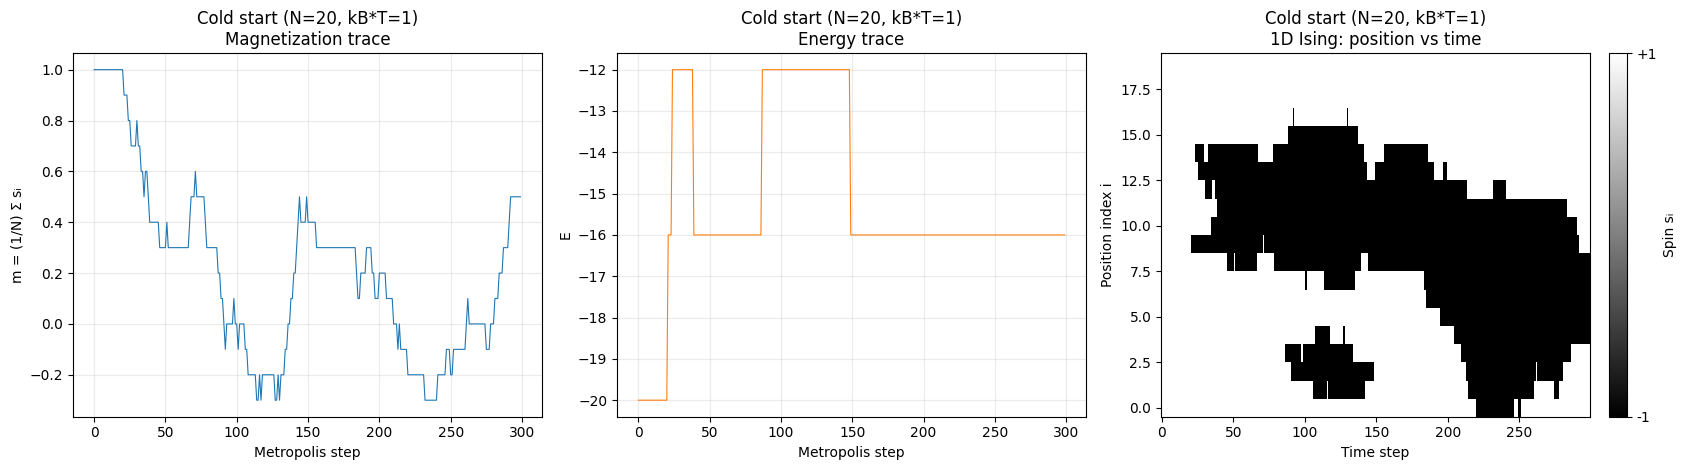


=== Hot start equilibration (random initial state) ===
Start mode: hot, N=20, J=1.0, kB*T=1.0
Initial s[N]:
+--+--++++--+-----+-

Trial   1: flip index 19, ΔE= -4.0, accepted
+--+--++++--+-----++

Trial   2: flip index  4, ΔE=  0.0, accepted
+--++-++++--+-----++

Trial   3: flip index 16, ΔE=  4.0, rejected
+--++-++++--+-----++

Trial   5: flip index  7, ΔE=  4.0, rejected
+--+++++++--+-----++

Trial  10: flip index 12, ΔE= -4.0, accepted
+---++++++--------++

Trial  20: flip index  7, ΔE= -4.0, accepted
----+++++++--------+

Trial  50: flip index  7, ΔE=  4.0, rejected
+++++++++++++------+

Trial 100: flip index  7, ΔE=  4.0, rejected
++++++++++++------++

Trial 200: flip index  0, ΔE=  4.0, rejected
++++++++++++++++--++

Trial 300: flip index 17, ΔE=  0.0, accepted
+++++++++++++++---++

Hot-start acceptance rate: 0.270
Hot-start final magnetization: 0.700


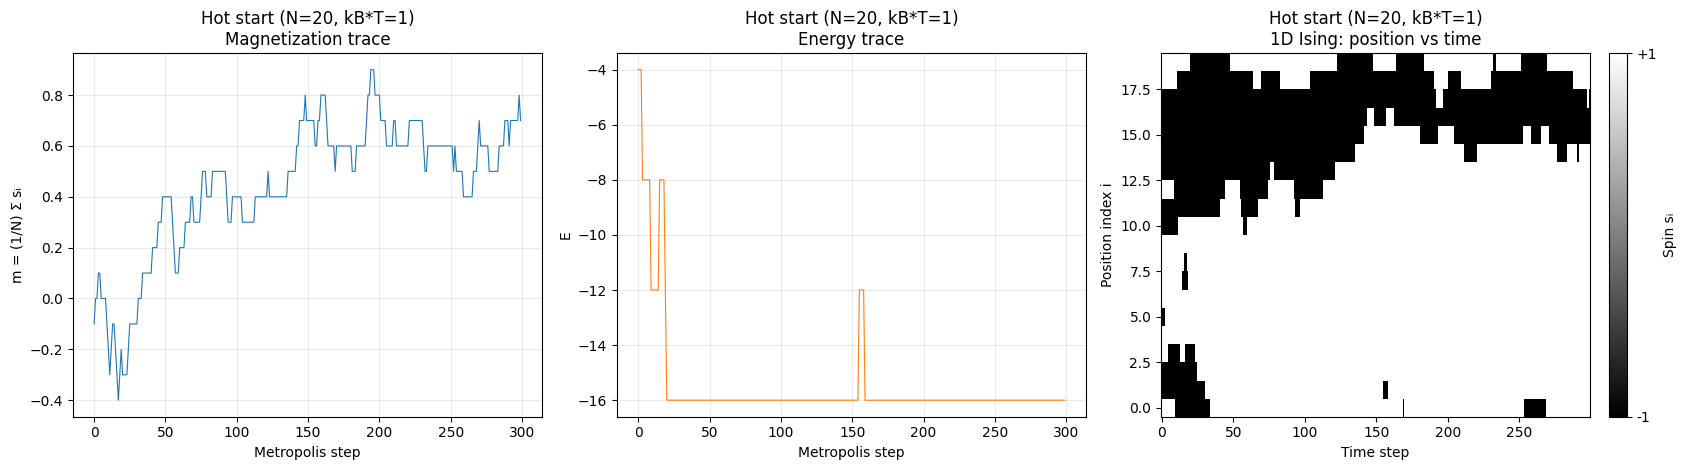

In [8]:
# Debug run: kB*T = 1, J = 1, N ≈ 20
J_debug = 1.0
T_debug = 1.0   # since kB=1 below, this means kB*T = 1
kB_debug = 1.0
N_debug = 20
n_steps_debug = 300
debug_trials = {1, 2, 3, 5, 10, 20, 50, 100, 200, 300}

print("=== Cold start equilibration (ordered initial state) ===")
cold = run_ising_metropolis(
    N=N_debug,
    T=T_debug,
    n_steps=n_steps_debug,
    start_mode="cold",
    J=J_debug,
    h=0.0,
    kB=kB_debug,
    seed=7,
    debug_trials=debug_trials,
)
print(f"Cold-start acceptance rate: {cold['accept_rate']:.3f}")
print(f"Cold-start final magnetization: {cold['mag_trace'][-1]:.3f}")
plot_ising_run_diagnostics(cold, title="Cold start (N=20, kB*T=1)")
print()

print("=== Hot start equilibration (random initial state) ===")
hot = run_ising_metropolis(
    N=N_debug,
    T=T_debug,
    n_steps=n_steps_debug,
    start_mode="hot",
    J=J_debug,
    h=0.0,
    kB=kB_debug,
    seed=8,
    debug_trials=debug_trials,
)
print(f"Hot-start acceptance rate: {hot['accept_rate']:.3f}")
print(f"Hot-start final magnetization: {hot['mag_trace'][-1]:.3f}")
plot_ising_run_diagnostics(hot, title="Hot start (N=20, kB*T=1)")

JC: now I can see the ising model, and the visuals are consistent with the ones in the book, but im gona go back and research what the magnetization and energy traces are doing

Start mode: cold, N=1000, J=1.0, kB*T=1.0
Initial s[N]:
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

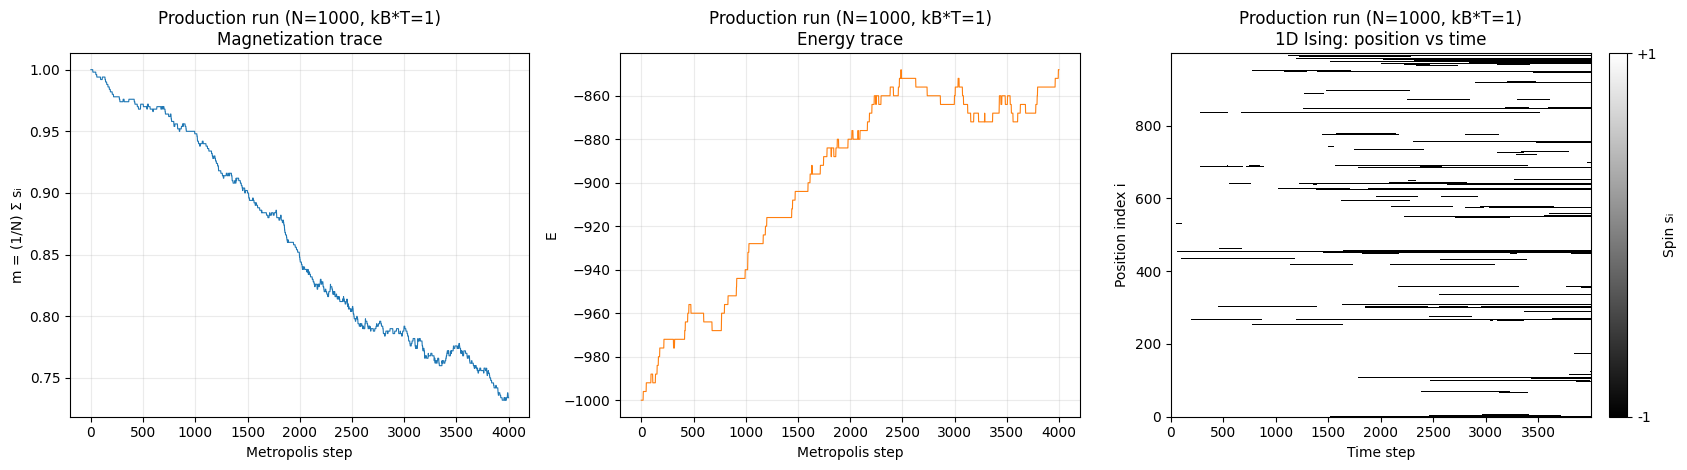

In [26]:
# Production-style run: larger N, still J fixed at 1
prod = run_ising_metropolis(
    N=1000,
    T=1.0,
    n_steps=4000,
    start_mode="cold",
    J=1.0,
    h=0.0,
    kB=1.0,
    seed=1234,
    debug_trials=None,  # keep output compact for larger systems
)

print("\n=== Production-style summary (N=1000) ===")
print(f"Acceptance rate: {prod['accept_rate']:.3f}")
print(f"Final magnetization: {prod['mag_trace'][-1]:.3f}")
print(f"Final energy: {prod['ene_trace'][-1]:.1f}")
plot_ising_run_diagnostics(prod, title="Production run (N=1000, kB*T=1)")

### JC: In a larger step the magnetization is going up and down which is on target because of the kBT factor of 1 and the randomness of the algorithm. But the energy trace seems like its tapering off asymptotically. I should test if its true for even larger steps

Start mode: hot, N=100000, J=1.0, kB*T=1.0
Initial s[N]:
+++--+----+-+-+-+++-+--+++++++++-++-+-++---+-+-++--+---+--+-++---++++-++--+++-+--++-++++-+--+-+---+-++-+--+-++-+----++-++--+++++---++++----++++-+-----+-+-+--+++-----+---+--++--+-+-+++-+-----+++-++-+--+--++------+-+---++-+--++--+--+++--+---++++-+++--++---+-++-+++++-++++-+--+-+--++-+-++-++-+--+--+--+--++++-++++++-+--+---+--+++---++++---+--------+-++++--++++++--+-+++-++--++----++++--+-+----+-+-++++--+++-++-++-+-++++-+-++++++-+--+---++--+----+---+++-+--+++----+----++++-+-----++---++-----+---++-+-+-+---+++-+-+-----+++--+-+-+---------++++-+-+------+-++--+--++++-+++++-+-+---++-+-++-++--+---+-------+-++---++-++++-+-++++-+-+---+----+--++--+++--++++--++-+++---++----+-++--------+---+++-+---++-+++-+-++---+++++-----+---+---++--+-++-+++-+-+++-+---++--+-+-+--++-+----++--++-+--+++++++--+++++---+-+++--+-++----+++++-++++++++-+--++-++-+-++-++-+---+--+--+-++------------++-+++-+--++--+---++++-+---+---++-++++--+-+--+++-+-++-+----+-++--+++-+-+-++++-+-+

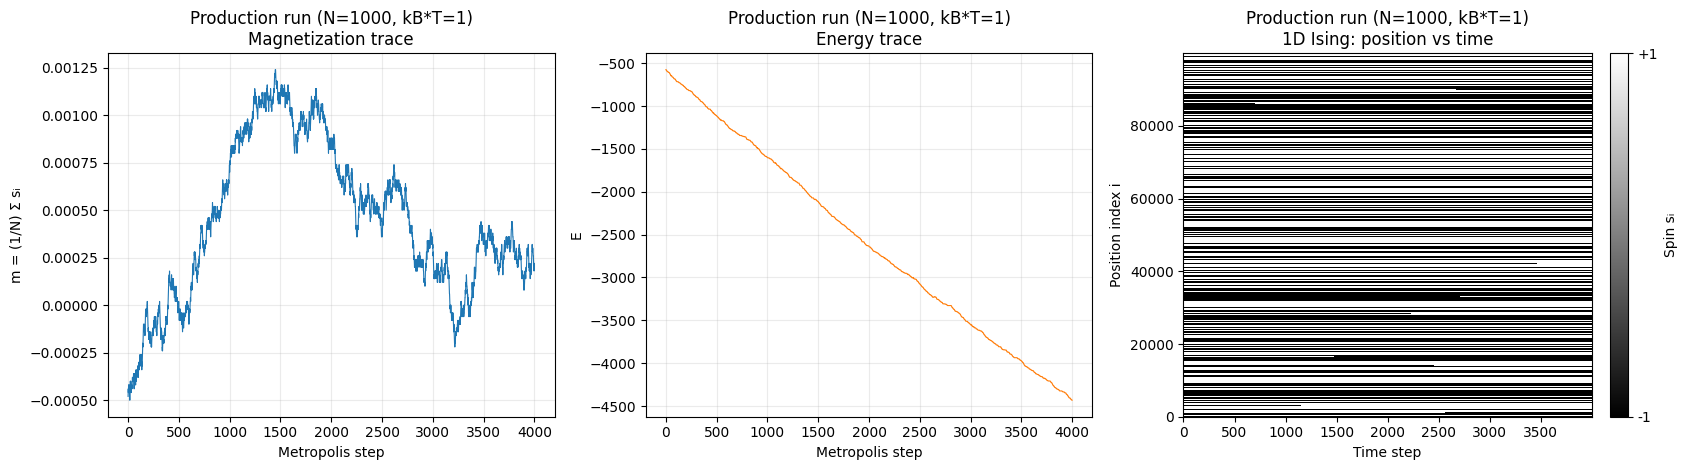

In [28]:
# Production-style run: larger N, still J fixed at 1
prod = run_ising_metropolis(
    N=100000,
    T=1.0,
    n_steps=4000,
    start_mode="hot",
    J=1.0,
    h=0.0,
    kB=1.0,
    seed=1234,
    debug_trials=None,  # keep output compact for larger systems
)

print("\n=== Production-style summary (N=1000) ===")
print(f"Acceptance rate: {prod['accept_rate']:.3f}")
print(f"Final magnetization: {prod['mag_trace'][-1]:.3f}")
print(f"Final energy: {prod['ene_trace'][-1]:.1f}")
plot_ising_run_diagnostics(prod, title="Production run (N=1000, kB*T=1)")

### JC: interestingly after a large step size the growth is decaying linearly, which is peculiar but could be made sense because at such a large time the random changes in energy average out. Also Interestingly the final magnetization is 0 which could be evidence that the spins all cancelled out.